Fem els inputs

In [5]:
# Core imports
import pandas as pd
import numpy as np
import time
import random
import pyautogui
import re
from datetime import datetime, timedelta

# Selenium imports
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import (
    TimeoutException, 
    NoSuchElementException,
    StaleElementReferenceException
)

# For automatic chromedriver management
from webdriver_manager.chrome import ChromeDriverManager

# For parsing HTML
from bs4 import BeautifulSoup

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


The first step is to do the scrapping

In [27]:
# FERHO AMB CLASSIFICATION NO AMB DICTIONARIES?
import time
import pandas as pd
import requests
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor

# Les pagines que vull van de la 63 a la 13012 (haure de treure algun del 2026 i del 2000 potser)
# 1 = [67,1050] (23 mins)
# 2 = [1051, 2100] (45 mins)
# 3 = [2101, 4100] (73 mins)
# 4 = [4101, 6000] (77 mins)
# 5 = [6001, 8000]
# 6 = [8001, 10000]
# 7 = [10001, 11000]
# 8 = [11001, 13017]

PAGE_START = 4101 
PAGE_END = 6000    

def get_obituaries_from_page(page_num):
    base_url = "https://www.currentobituary.com"
    url = f"{base_url}/browse/p/{page_num}"
    try:
        r = requests.get(url, timeout=15)
        if r.status_code != 200: return []
        
        soup = BeautifulSoup(r.text, 'html.parser')
        items = []
        
        for el in soup.select(".username"):
            span = el.select_one("span")
            link = el.select_one("a")
            
            if span and link:
                date_txt = span.get_text().strip()
                href = link['href']
                
                # CORRECCIÓ: Si la URL és relativa, hi afegim la base
                full_url = href if href.startswith("http") else base_url + href
                
               
                items.append({
                    "url": full_url,
                    "data": date_txt
                })
        return items
    except:
        return []

def get_biografia_fast(url):
    try:
        r = requests.get(url, timeout=10)
        soup = BeautifulSoup(r.text, 'html.parser')
        container = soup.find(id="tab-obituary")
        if container:
            paragraphs = container.find_all("p")
            if paragraphs:
                txt = max([p.get_text().strip() for p in paragraphs], key=len)
                return txt if len(txt) > 50 else "Text massa curt"
        return "Text no trobat"
    except:
        return "Error"   

def fetch_full_data(item):
    item['biografia'] = get_biografia_fast(item['url'])
    return item

# --- EXECUCIÓ ---

if __name__ == "__main__":
    all_links = []
        
    # PAS 1: Recollir URLs (sense Selenium, només Requests = velocitat màxima)
    for p in range(PAGE_START, PAGE_END + 1):
        found = get_obituaries_from_page(p)
        if found:
            all_links.extend(found)
            # Si trobem dades, anem imprimint per saber on som
            print(f"    📄 Pàgina {p}: Trobats {len(found)} casos. (Total acumulat: {len(all_links)})")
        
        if p % 10 == 0: time.sleep(1) # Pausa per no ser bloquejats

    # PAS 2: Scraping de biografies
    if not all_links:
        print("❌ No s'ha trobat res. Prova d'ajustar PAGE_START.")
    else:
        print(f"\n📂 Iniciant scraping de {len(all_links)} biografies...")
        final_results = []
        
        # Usem ThreadPool per anar ràpid
        with ThreadPoolExecutor(max_workers=10) as executor:
            final_results = list(executor.map(fetch_full_data, all_links))
        
        # Guardat final
        df = pd.DataFrame(final_results)
        df.to_csv("obituaris_4_FINAL.csv", index=False, encoding='utf-8-sig')
        print("✅ FET! Arxiu 'obituaris_4_FINAL.csv' generat.")

    📄 Pàgina 4101: Trobats 20 casos. (Total acumulat: 20)
    📄 Pàgina 4102: Trobats 20 casos. (Total acumulat: 40)
    📄 Pàgina 4103: Trobats 20 casos. (Total acumulat: 60)
    📄 Pàgina 4104: Trobats 20 casos. (Total acumulat: 80)
    📄 Pàgina 4105: Trobats 20 casos. (Total acumulat: 100)
    📄 Pàgina 4106: Trobats 20 casos. (Total acumulat: 120)
    📄 Pàgina 4107: Trobats 20 casos. (Total acumulat: 140)
    📄 Pàgina 4108: Trobats 20 casos. (Total acumulat: 160)
    📄 Pàgina 4109: Trobats 20 casos. (Total acumulat: 180)
    📄 Pàgina 4110: Trobats 20 casos. (Total acumulat: 200)
    📄 Pàgina 4111: Trobats 20 casos. (Total acumulat: 220)
    📄 Pàgina 4112: Trobats 20 casos. (Total acumulat: 240)
    📄 Pàgina 4113: Trobats 20 casos. (Total acumulat: 260)
    📄 Pàgina 4114: Trobats 20 casos. (Total acumulat: 280)
    📄 Pàgina 4115: Trobats 20 casos. (Total acumulat: 300)
    📄 Pàgina 4116: Trobats 20 casos. (Total acumulat: 320)
    📄 Pàgina 4117: Trobats 20 casos. (Total acumulat: 340)
 

Fer el csv final ajuntant tots els csv i aplicant els filtres necessaris (treure els duplicats, treure anys <2001 o >2025, treure els que tinguuin menys de 100 caracters i treure la part del funeral)

In [29]:
import pandas as pd
import re

# 1. Definim els noms dels fitxers i paraules de tall
fitxers = [f'obituaris_{i}_FINAL.csv' for i in range(1, 9)]

paraules_tall = [
    "funeral service", "calling hours", "burial will be", 
    "interment", "cremation", "in lieu of flowers", 
    "memorial mass", "visitation will", "Directions to funeral"
]

def neteja_i_talla_text(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Passem a minúscules per fer la cerca més fàcil
    text_lower = text.lower()
    posicio_tall = len(text)
    
    # Busquem la paraula de tall que aparegui primer
    for paraula in paraules_tall:
        index = text_lower.find(paraula.lower())
        if index != -1 and index < posicio_tall:
            posicio_tall = index
            
    # Tallem el text i traiem espais en blanc sobrants al final
    return text[:posicio_tall].strip()

try:
    # 2. Carreguem i concatenem
    df = pd.concat([pd.read_csv(f) for f in fitxers], ignore_index=True)
    print(f"Registres inicials: {len(df)}")

    # 3. Duplicats i dates
    df = df.drop_duplicates(subset=['url'])
    df['data'] = pd.to_datetime(df['data'], errors='coerce')

    # 4. APLICAR TALL DE TEXT (Suposant que la columna es diu 'biografia')
    # Ajusta 'text' al nom real de la teva columna
    df['biografia'] = df['biografia'].apply(neteja_i_talla_text)
    print("Textos tallats segons paraules clau de funeral.")

    # 5. FILTRAR PER LONGITUD (mínim 100 caràcters)
    df = df[df['biografia'].str.len() >= 100]
    print(f"Registres després de filtrar per longitud (>100 car.): {len(df)}")

    # 6. FILTRAR PER DATA (2001-2025)
    df_final = df[
        (df['data'].dt.year >= 2001) & 
        (df['data'].dt.year <= 2025)
    ].copy()

    # 7. Guardem
    df_final.to_csv('obituaris_TOTAL_net.csv', index=False)
    
    print("--- Procés finalitzat amb èxit ---")
    print(f"Registres finals: {len(df_final)}")

except Exception as e:
    print(f"Error: {e}")

Registres inicials: 254520
Textos tallats segons paraules clau de funeral.
Registres després de filtrar per longitud (>100 car.): 238490
--- Procés finalitzat amb èxit ---
Registres finals: 238487


Separar entre nois i noies

In [32]:
import pandas as pd
import re

def detectar_genere(text):
    if not isinstance(text, str):
        return "Unknown"
    
    # Definim llistes de paraules clau (en minúscules)
    masculi = r'\b(he|his|him|himself|mr)\b'
    femeni = r'\b(she|her|hers|herself|mrs|ms|miss)\b'
    
    # Comptem aparicions (usant regex per evitar que "she" compti dins de "fisher")
    count_m = len(re.findall(masculi, text.lower()))
    count_f = len(re.findall(femeni, text.lower()))
    
    if count_m > count_f:
        return "M"
    elif count_f > count_m:
        return "F"
    else:
        return "Unknown" # En cas d'empat o falta de pronoms

try:
    # 1. Carreguem el fitxer net que hem creat abans
    df = pd.read_csv('obituaris_TOTAL_net.csv')
    
    # Identifiquem la columna (ara ja sabem que es diu 'biografia' o similar)
    # Si la teva columna es diu 'text', canvia 'biografia' per 'text'
    col_text = 'biografia' if 'biografia' in df.columns else 'text'
    
    print(f"Assignant gènere basat en la columna: '{col_text}'...")

    # 2. Apliquem la funció fila per fila
    df['gender'] = df[col_text].apply(detectar_genere)

    # 3. Estadístiques ràpides
    print("Resultats del classificador de gènere:")
    print(df['gender'].value_counts())

    # 4. Guardem el fitxer final amb la nova columna
    df.to_csv('obituaris_TOTAL_gender.csv', index=False)
    print("\n--- Procés finalitzat ---")
    print("Fitxer guardat com: obituaris_TOTAL_gender.csv")

except Exception as e:
    print(f"Error: {e}")

Assignant gènere basat en la columna: 'biografia'...
Resultats del classificador de gènere:
gender
F          109965
M          105599
Unknown     22923
Name: count, dtype: int64

--- Procés finalitzat ---
Fitxer guardat com: obituaris_TOTAL_gender.csv


Faig algunes comprovacions amb diccionaris molt basics fets amb chat SENSE SEPARAR ENTRE HOMES I DONES

--- EVOLUCIÓ DE L'ÍNDEX RELIGIÓS PER ANYS ---
any
2001    1.819191
2002    1.709410
2003    1.641212
2004    1.590257
2005    1.656387
2006    1.662669
2007    1.646667
2008    1.545453
2009    1.512918
2010    1.492918
2011    1.485330
2012    1.425406
2013    1.412360
2014    1.394532
2015    1.370162
2016    1.352998
2017    1.284027
2018    1.261576
2019    1.164093
2020    0.985606
2021    1.036626
2022    1.001005
2023    1.026832
2024    1.020639
2025    1.020050
Name: rel_index, dtype: float64


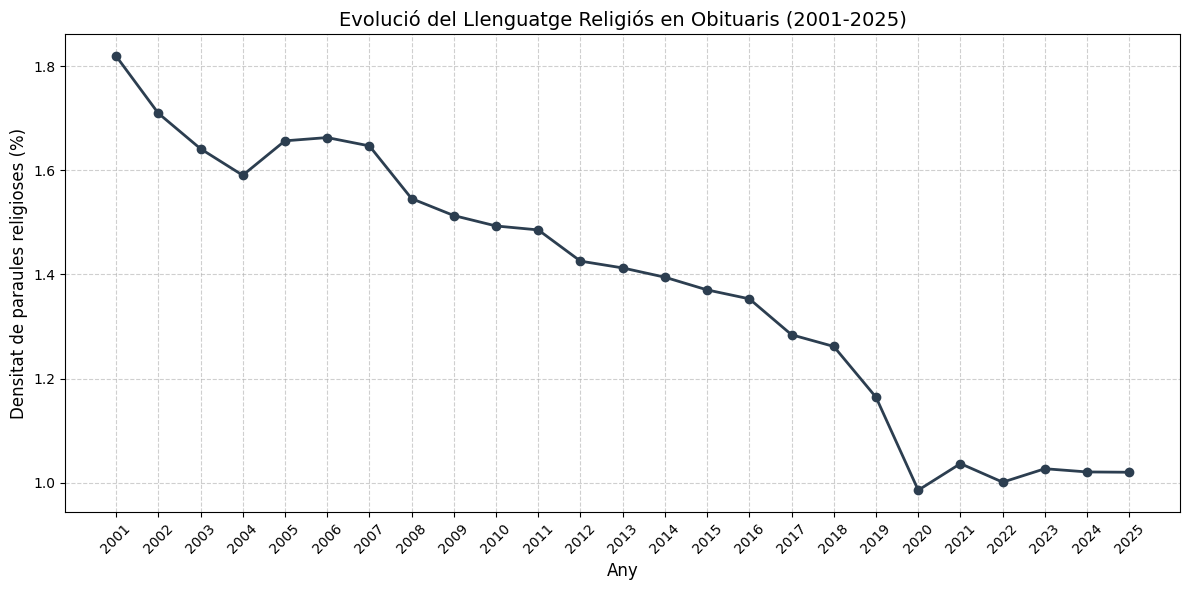

In [6]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. DICCIONARI RELIGIÓS
religion_dict = [
    'church', 'faith', 'god', 'jesus', 'christ', 'lord', 'pastor', 'reverend', 
    'priest', 'bible', 'scripture', 'catholic', 'baptist', 'methodist', 
    'christian', 'faithfully', 'heaven', 'blessed', 'prayer', 'pray', 
    'ministry', 'choir', 'spirit', 'spiritual', 'soul', 'devout', 'parish',
    'mass', 'vatican', 'amen', 'worship', 'congregation', 'clerical'
]

def get_religious_index(text):
    text = str(text).lower()
    # Tokenització: paraules de 3+ lletres
    words = re.findall(r'\b\w{3,}\b', text)
    if not words: return 0
    
    # Comptem coincidències
    count = sum(1 for word in words if any(rel_word in word for rel_word in religion_dict))
    return (count / len(words)) * 100

# 2. CÀRREGA DEL FITXER TOTAL NETEJAT
try:
    df = pd.read_csv('obituaris_TOTAL_net.csv')
    
    # Assegurem que la columna 'data' és datetime i 'biografia' no té buits
    df['data'] = pd.to_datetime(df['data'])
    df = df.dropna(subset=['biografia'])
    
    # Netegem errors de scraping si n'hi hagués
    df = df[~df['biografia'].str.contains("Error|Text no trobat|massa curt", case=False)]

    # 3. EXTRACCION DE L'ANY I CÀLCUL DE L'ÍNDEX
    df['any'] = df['data'].dt.year
    df['rel_index'] = df['biografia'].apply(get_religious_index)

    # 4. AGRUPACIÓ PER ANY (MITJANA)
    # Creem una sèrie on l'índex és l'any i el valor és la mitjana de religiositat
    evolucio_religiosa = df.groupby('any')['rel_index'].mean()

    # 5. RESULTATS PER PANTALLA
    print("--- EVOLUCIÓ DE L'ÍNDEX RELIGIÓS PER ANYS ---")
    print(evolucio_religiosa)

    # 6. VISUALITZACIÓ (Gràfic de línies per veure la tendència)
    plt.figure(figsize=(12, 6))
    evolucio_religiosa.plot(kind='line', marker='o', color='#2c3e50', linewidth=2)
    
    plt.title('Evolució del Llenguatge Religiós en Obituaris (2001-2025)', fontsize=14)
    plt.xlabel('Any', fontsize=12)
    plt.ylabel('Densitat de paraules religioses (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(evolucio_religiosa.index, rotation=45) # Perquè es vegin tots els anys
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Error: No s'ha trobat el fitxer 'obituaris_TOTAL_net.csv'.")
except Exception as e:
    print(f"S'ha produït un error: {e}")

--- EVOLUCIÓ DE L'ÍNDEX PROFESSIONAL PER ANYS ---
any
2001    1.872718
2002    1.472577
2003    1.548856
2004    1.436488
2005    1.413420
2006    1.344338
2007    1.332549
2008    1.392606
2009    1.400013
2010    1.413062
2011    1.432654
2012    1.380009
2013    1.405519
2014    1.416528
2015    1.362648
2016    1.347391
2017    1.355534
2018    1.311308
2019    1.273909
2020    1.287449
2021    1.257896
2022    1.269215
2023    1.244999
2024    1.210037
2025    1.252423
Name: prof_index, dtype: float64


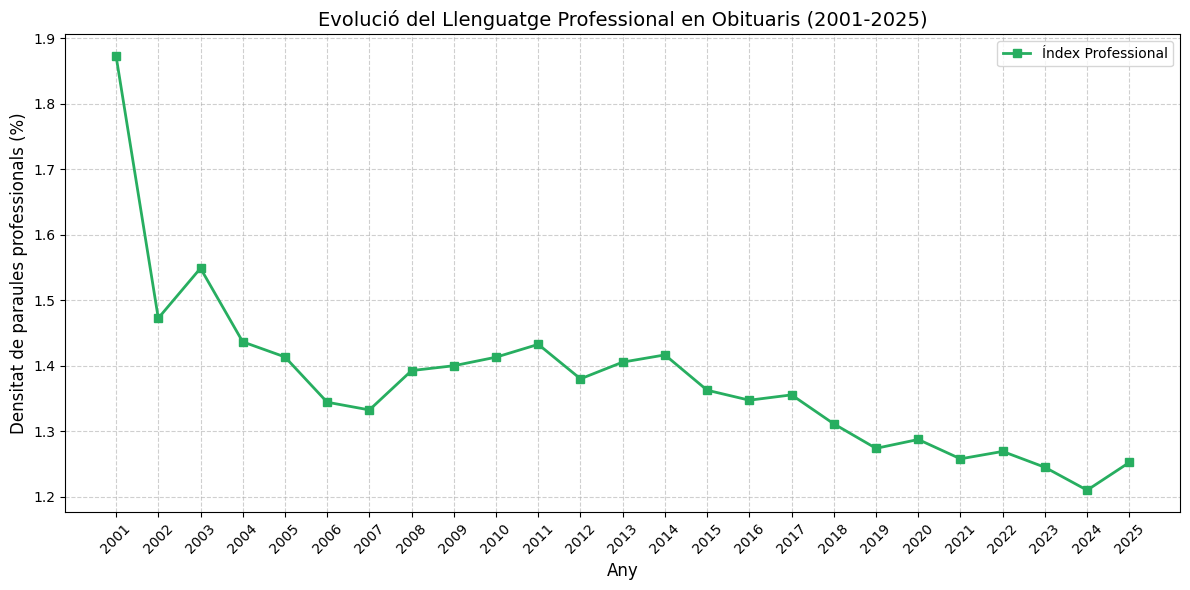

In [31]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. DICCIONARI PROFESSIONAL
professional_dict = [
    'career', 'retired', 'worked', 'employed', 'professor', 'teacher', 
    'engineer', 'manager', 'director', 'business', 'company', 'university', 
    'degree', 'graduated', 'college', 'professional', 'owner', 'founder', 
    'department', 'industry', 'office', 'corporation', 'executive', 'nurse',
    'doctor', 'military', 'veteran', 'served', 'army', 'navy', 'position'
]

def get_professional_index(text):
    text = str(text).lower()
    # Tokenització: paraules de 3+ lletres
    words = re.findall(r'\b\w{3,}\b', text)
    if not words: return 0
    
    # Comptem coincidències amb el diccionari professional
    count = sum(1 for word in words if any(prof_word in word for prof_word in professional_dict))
    
    # Retornem el percentatge de densitat
    return (count / len(words)) * 100

# 2. CÀRREGA I PROCESSAMENT
try:
    # Carreguem el fitxer que ja tenim netejat dels passos anteriors
    df = pd.read_csv('obituaris_TOTAL_net.csv')
    
    # Netegem dades i preparem columnes
    df['data'] = pd.to_datetime(df['data'])
    df = df.dropna(subset=['biografia'])
    df = df[~df['biografia'].str.contains("Error|Text no trobat|massa curt", case=False)]
    
    # Creem la columna de l'any
    df['any'] = df['data'].dt.year

    # 3. CÀLCUL DE L'ÍNDEX PROFESSIONAL
    df['prof_index'] = df['biografia'].apply(get_professional_index)

    # 4. AGRUPACIÓ PER ANY (MITJANA)
    evolucio_professional = df.groupby('any')['prof_index'].mean()

    # 5. RESULTATS PER PANTALLA
    print("--- EVOLUCIÓ DE L'ÍNDEX PROFESSIONAL PER ANYS ---")
    print(evolucio_professional)

    # 6. VISUALITZACIÓ
    plt.figure(figsize=(12, 6))
    
    # Fem servir un color diferent (verd corporatiu) per diferenciar-ho del religiós
    evolucio_professional.plot(kind='line', marker='s', color='#27ae60', linewidth=2, label='Índex Professional')
    
    plt.title('Evolució del Llenguatge Professional en Obituaris (2001-2025)', fontsize=14)
    plt.xlabel('Any', fontsize=12)
    plt.ylabel('Densitat de paraules professionals (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(evolucio_professional.index, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Error: No s'ha trobat el fitxer 'obituaris_TOTAL_net.csv'.")
except Exception as e:
    print(f"S'ha produït un error inesperat: {e}")

--- EVOLUCIÓ DE L'ÍNDEX FAMILIAR PER ANYS ---
any
2007    7.703986
2008    7.916418
2009    7.959400
2010    8.033366
2011    8.188398
2012    8.139600
2013    8.043087
2014    7.976790
2015    7.860996
2016    7.814044
2017    7.702474
2018    7.619319
2019    7.497846
2020    7.548526
2021    7.423806
2022    7.455523
2023    7.302138
2024    7.070425
2025    7.130071
Name: fam_index, dtype: float64


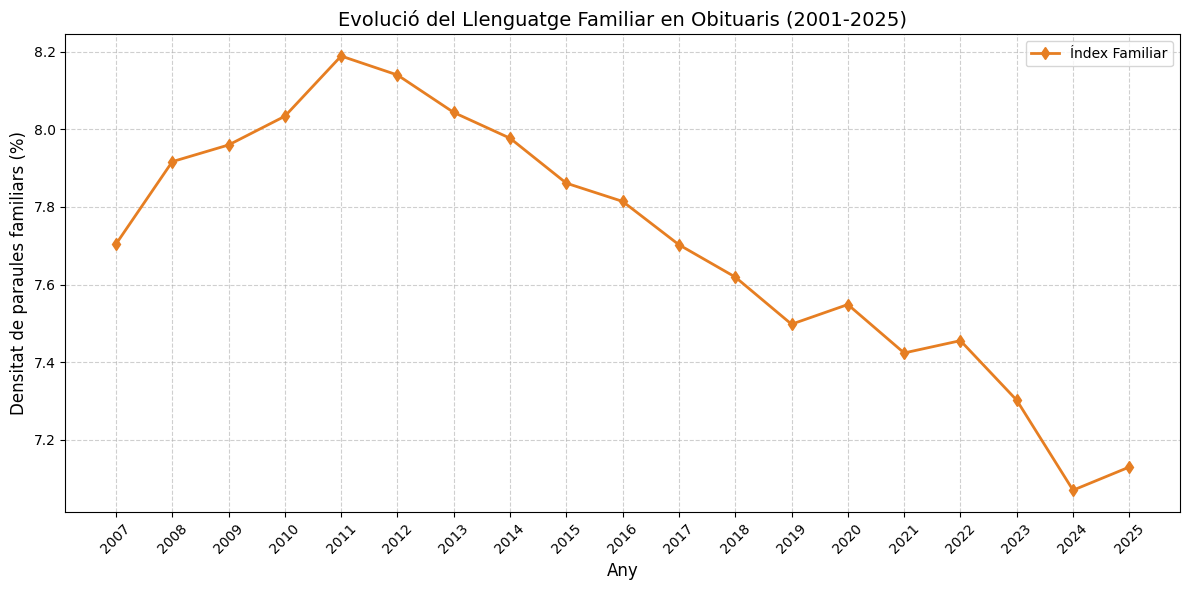

In [12]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. DICCIONARI FAMILIAR
family_dict = [
    'family', 'mother', 'father', 'son', 'daughter', 'brother', 'sister',
    'grandchild', 'grandchildren', 'grandson', 'granddaughter', 'grandmother',
    'grandfather', 'nana', 'papa', 'niece', 'nephew', 'cousin', 'aunt', 'uncle',
    'husband', 'wife', 'spouse', 'partner', 'loving', 'beloved', 'devoted',
    'survived', 'children', 'great-grandchildren', 'parent'
]

def get_family_index(text):
    text = str(text).lower()
    # Tokenització: paraules de 3+ lletres
    words = re.findall(r'\b\w{3,}\b', text)
    if not words: return 0
    
    # Comptem coincidències amb el diccionari familiar
    count = sum(1 for word in words if any(fam_word in word for fam_word in family_dict))
    
    # Retornem el percentatge de densitat
    return (count / len(words)) * 100

# 2. CÀRREGA I PROCESSAMENT
try:
    df = pd.read_csv('obituaris_TOTAL_net.csv')
    
    # Neteja i preparació
    df['data'] = pd.to_datetime(df['data'])
    df = df.dropna(subset=['biografia'])
    df = df[~df['biografia'].str.contains("Error|Text no trobat|massa curt", case=False)]
    df['any'] = df['data'].dt.year

    # 3. CÀLCUL DE L'ÍNDEX FAMILIAR
    df['fam_index'] = df['biografia'].apply(get_family_index)

    # 4. AGRUPACIÓ PER ANY (MITJANA)
    evolucio_familiar = df.groupby('any')['fam_index'].mean()

    # 5. RESULTATS
    print("--- EVOLUCIÓ DE L'ÍNDEX FAMILIAR PER ANYS ---")
    print(evolucio_familiar)

    # 6. VISUALITZACIÓ
    plt.figure(figsize=(12, 6))
    
    # Utilitzem un color càlid (taronja/vermell) per a la família
    evolucio_familiar.plot(kind='line', marker='d', color='#e67e22', linewidth=2, label='Índex Familiar')
    
    plt.title('Evolució del Llenguatge Familiar en Obituaris (2001-2025)', fontsize=14)
    plt.xlabel('Any', fontsize=12)
    plt.ylabel('Densitat de paraules familiars (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(evolucio_familiar.index, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Error: No s'ha trobat el fitxer 'obituaris_TOTAL_net.csv'.")
except Exception as e:
    print(f"S'ha produït un error: {e}")

--- EVOLUCIÓ DE L'ÍNDEX LIFESTYLE PER ANYS ---
any
2014    1.272279
2015    1.280151
2016    1.304195
2017    1.359314
2018    1.371047
2019    1.410489
2020    1.509862
2021    1.608773
2022    1.667489
2023    1.676992
2024    1.681535
2025    1.684368
Name: life_index, dtype: float64


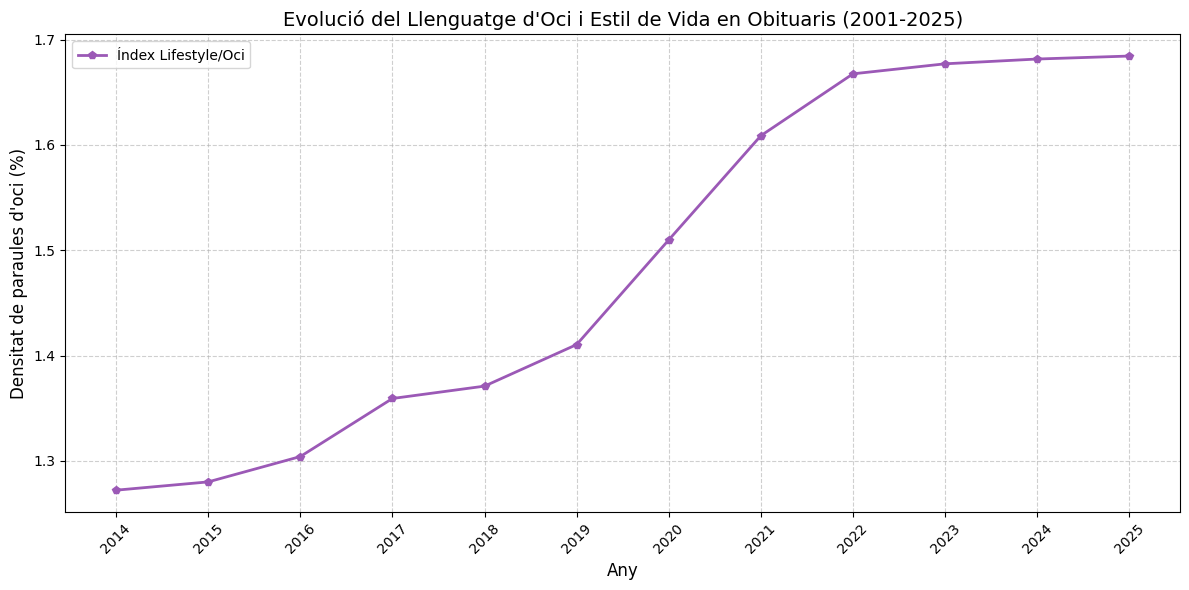

In [8]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. DICCIONARI D'ESTIL DE VIDA (LIFESTYLE)
lifestyle_dict = [
    'travel', 'traveled', 'journey', 'adventure', 'hiking', 'sailing', 'golf', 
    'gardening', 'cooking', 'music', 'concerts', 'art', 'reading', 'books', 
    'nature', 'outdoors', 'animals', 'dogs', 'cats', 'pets', 'beach', 'lake',
    'traveling', 'passion', 'enjoyed', 'hobbies', 'photography', 'sports', 
    'fan', 'watching', 'food', 'wine', 'restaurant', 'club', 'fishing', 
    'camping', 'collector', 'painting', 'dance', 'dancing', 'volunteering'
]

def get_lifestyle_index(text):
    text = str(text).lower()
    # Tokenització: paraules de 3+ lletres
    words = re.findall(r'\b\w{3,}\b', text)
    if not words: return 0
    
    # Comptem coincidències amb el diccionari de lifestyle
    count = sum(1 for word in words if any(ls_word in word for ls_word in lifestyle_dict))
    
    # Retornem el percentatge de densitat
    return (count / len(words)) * 100

# 2. CÀRREGA I PROCESSAMENT
try:
    df = pd.read_csv('obituaris_TOTAL_net.csv')
    
    # Neteja de dades
    df['data'] = pd.to_datetime(df['data'])
    df = df.dropna(subset=['biografia'])
    df = df[~df['biografia'].str.contains("Error|Text no trobat|massa curt", case=False)]
    df['any'] = df['data'].dt.year

    # 3. CÀLCUL DE L'ÍNDEX LIFESTYLE
    df['life_index'] = df['biografia'].apply(get_lifestyle_index)

    # 4. AGRUPACIÓ PER ANY (MITJANA)
    evolucio_lifestyle = df.groupby('any')['life_index'].mean()

    # 5. RESULTATS PER PANTALLA
    print("--- EVOLUCIÓ DE L'ÍNDEX LIFESTYLE PER ANYS ---")
    print(evolucio_lifestyle)

    # 6. VISUALITZACIÓ
    plt.figure(figsize=(12, 6))
    
    # Fem servir un color lila o magenta per representar l'oci i la personalitat
    evolucio_lifestyle.plot(kind='line', marker='p', color='#9b59b6', linewidth=2, label='Índex Lifestyle/Oci')
    
    plt.title('Evolució del Llenguatge d\'Oci i Estil de Vida en Obituaris (2001-2025)', fontsize=14)
    plt.xlabel('Any', fontsize=12)
    plt.ylabel('Densitat de paraules d\'oci (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(evolucio_lifestyle.index, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Error: No s'ha trobat el fitxer 'obituaris_TOTAL_net.csv'.")
except Exception as e:
    print(f"S'ha produït un error: {e}")

Faig algunes comprovacions amb diccionaris molt basics fets amb chat SEPARANT ENTRE HOMES I DONES

Calculant índex religiós...


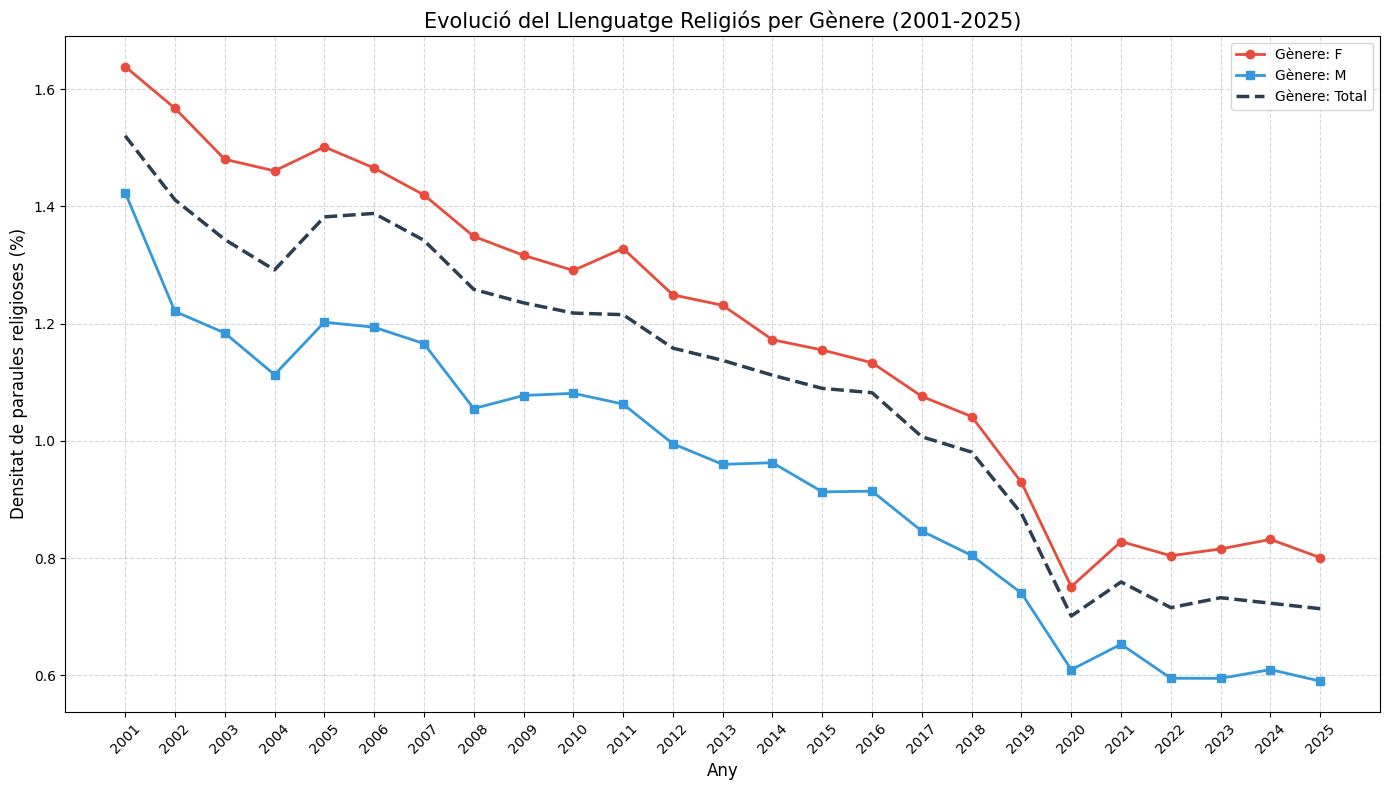


--- MITJANES PER GÈNERE (Tota la sèrie) ---
gender
F          1.157452
M          0.911181
Unknown    1.435473
Name: rel_index, dtype: float64


In [10]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. DICCIONARI RELIGIÓS
religion_dict = [
    'church', 'faith', 'god', 'jesus', 'christ', 'lord', 'pastor', 'reverend', 
    'priest', 'bible', 'scripture', 'catholic', 'baptist', 'methodist', 
    'christian', 'faithfully', 'heaven', 'blessed', 'prayer', 'pray', 
    'ministry', 'choir', 'spirit', 'spiritual', 'soul', 'devout', 'parish',
    'mass', 'vatican', 'amen', 'worship', 'congregation', 'clerical'
]

def get_religious_index(text):
    if pd.isna(text): return 0
    text = str(text).lower()
    words = re.findall(r'\b\w{3,}\b', text)
    if not words: return 0
    # Coincidència exacta de paraula
    count = sum(1 for word in words if word in religion_dict)
    return (count / len(words)) * 100

# 2. CÀRREGA DEL FITXER
try:
    df = pd.read_csv('obituaris_TOTAL_gender.csv')
    
    df['data'] = pd.to_datetime(df['data'], errors='coerce')
    df = df.dropna(subset=['biografia', 'data']) # No eliminem NAs de gender per veure els Unknown
    
    # 3. EXTRACCIÓ DE L'ANY I FILTRATGE
    df['any'] = df['data'].dt.year
    df = df[(df['any'] >= 2001) & (df['any'] <= 2025)].copy()
    
    print("Calculant índex religiós...")
    df['rel_index'] = df['biografia'].apply(get_religious_index)

    # 4. AGRUPACIÓ (Alternativa a reshape per evitar l'error)
    # Fem servir pivot_table que és més robust que groupby + unstack
    evolucio_genere = df.pivot_table(index='any', columns='gender', values='rel_index', aggfunc='mean')

    # Afegim la columna del Total
    evolucio_genere['Total'] = df.groupby('any')['rel_index'].mean()

    # 5. VISUALITZACIÓ
    plt.figure(figsize=(14, 8))
    
    # Definim estils per a totes les categories (F, M, Unknown, Total)
    estils_config = {
        'F': {'color': '#e74c3c', 'marker': 'o', 'ls': '-'},     # Vermell
        'M': {'color': '#3498db', 'marker': 's', 'ls': '-'},     # Blau
        'Total': {'color': '#2c3e50', 'marker': None, 'ls': '--'} # Negre/Gris fosc
    }
    
    for cat in ['F', 'M', 'Total']:
        if cat in evolucio_genere.columns:
            config = estils_config.get(cat)
            plt.plot(evolucio_genere.index, evolucio_genere[cat], 
                     label=f'Gènere: {cat}', 
                     color=config['color'], 
                     marker=config['marker'], 
                     linestyle=config['ls'], 
                     linewidth=2.5 if cat == 'Total' else 2)
    
    plt.title('Evolució del Llenguatge Religiós per Gènere (2001-2025)', fontsize=15)
    plt.xlabel('Any', fontsize=12)
    plt.ylabel('Densitat de paraules religioses (%)', fontsize=12)
    plt.legend(frameon=True)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(range(2001, 2026), rotation=45)
    
    plt.tight_layout()
    plt.show()

    print("\n--- MITJANES PER GÈNERE (Tota la sèrie) ---")
    print(df.groupby('gender')['rel_index'].mean())

except Exception as e:
    print(f"Error: {e}")

Calculant índex professional per gènere...


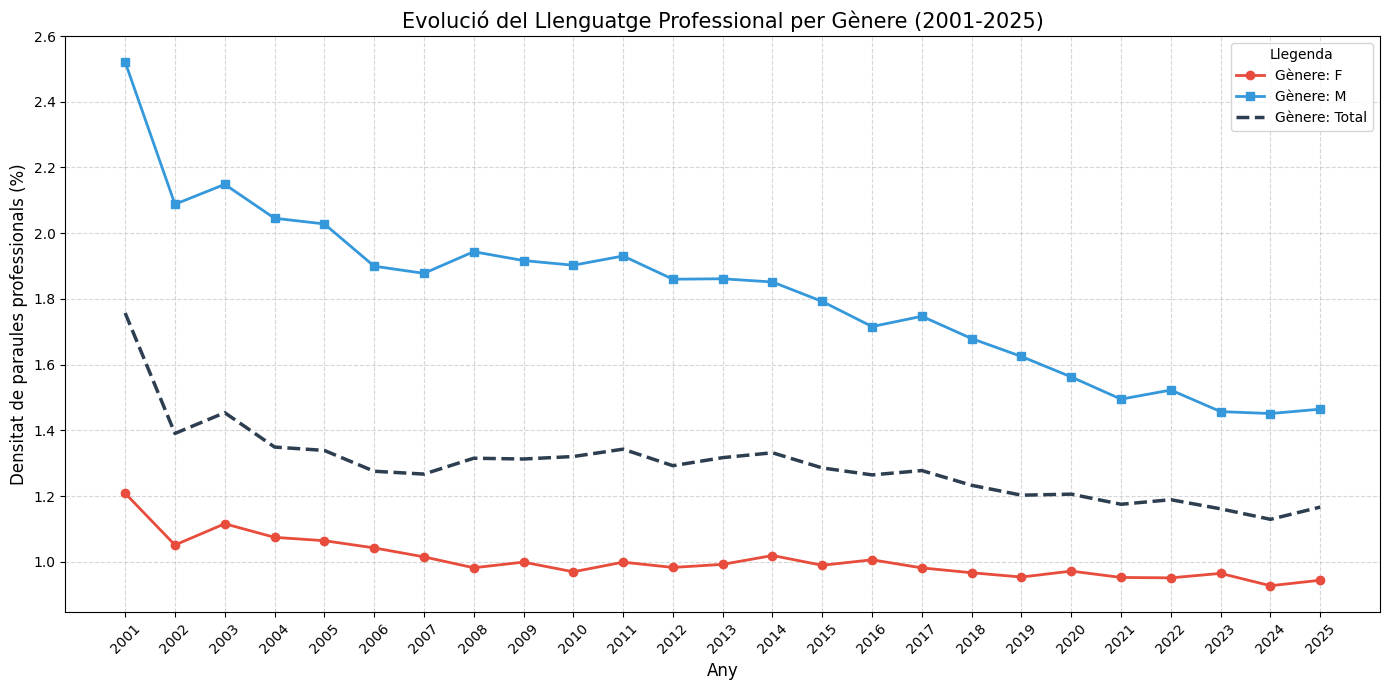


--- MITJANA D'ÍNDEX PROFESSIONAL PER GÈNERE ---
gender
F          0.990936
M          1.773459
Unknown    0.333113
Name: prof_index, dtype: float64


In [9]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. DICCIONARI PROFESSIONAL
professional_dict = [
    'career', 'retired', 'worked', 'employed', 'professor', 'teacher', 
    'engineer', 'manager', 'director', 'business', 'company', 'university', 
    'degree', 'graduated', 'college', 'professional', 'owner', 'founder', 
    'department', 'industry', 'office', 'corporation', 'executive', 'nurse',
    'doctor', 'military', 'veteran', 'served', 'army', 'navy', 'position'
]

def get_professional_index(text):
    if pd.isna(text): return 0
    text = str(text).lower()
    # Tokenització: paraules de 3+ lletres
    words = re.findall(r'\b\w{3,}\b', text)
    if not words: return 0
    
    # Comptem coincidències exactes amb el diccionari professional
    count = sum(1 for word in words if word in professional_dict)
    return (count / len(words)) * 100

# 2. CÀRREGA DEL FITXER AMB GÈNERE
try:
    # Usem el fitxer que inclou la classificació de gènere
    df = pd.read_csv('obituaris_TOTAL_gender.csv')
    
    # Preparació i neteja
    df['data'] = pd.to_datetime(df['data'], errors='coerce')
    df = df.dropna(subset=['biografia', 'data', 'gender'])
    df['any'] = df['data'].dt.year
    
    # Filtrem el rang temporal (2001-2025)
    df = df[(df['any'] >= 2001) & (df['any'] <= 2025)]

    print("Calculant índex professional per gènere...")
    df['prof_index'] = df['biografia'].apply(get_professional_index)

    # 3. AGRUPACIÓ PER ANY I GÈNERE (Taula Pivot)
    evolucio_genere_prof = df.groupby(['any', 'gender'])['prof_index'].mean().unstack()

    # Afegim la línia del TOTAL
    evolucio_genere_prof['Total'] = df.groupby('any')['prof_index'].mean()

    # 4. VISUALITZACIÓ
    plt.figure(figsize=(14, 7))
    
    # Colors: Verd per a professionalisme, amb blau i vermell per gènere
    estils_config = {
        'F': {'color': '#e74c3c', 'marker': 'o', 'ls': '-'},     # Vermell
        'M': {'color': '#3498db', 'marker': 's', 'ls': '-'},     # Blau
        'Total': {'color': '#2c3e50', 'marker': None, 'ls': '--'} # Negre/Gris fosc
    }
    
    for cat in ['F', 'M', 'Total']:
        if cat in evolucio_genere_prof.columns:
            config = estils_config.get(cat)
            plt.plot(evolucio_genere_prof.index, evolucio_genere_prof[cat], 
                     label=f'Gènere: {cat}', 
                     color=config['color'], 
                     marker=config['marker'], 
                     linestyle=config['ls'], 
                     linewidth=2.5 if cat == 'Total' else 2)
            
    
    plt.title('Evolució del Llenguatge Professional per Gènere (2001-2025)', fontsize=15)
    plt.xlabel('Any', fontsize=12)
    plt.ylabel('Densitat de paraules professionals (%)', fontsize=12)
    plt.legend(title="Llegenda")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(range(2001, 2026), rotation=45)
    
    plt.tight_layout()
    plt.show()

    # 5. RESUM PER GÈNERE
    print("\n--- MITJANA D'ÍNDEX PROFESSIONAL PER GÈNERE ---")
    print(df.groupby('gender')['prof_index'].mean())

except Exception as e:
    print(f"S'ha produït un error: {e}")

Calculant índex familiar per gènere...


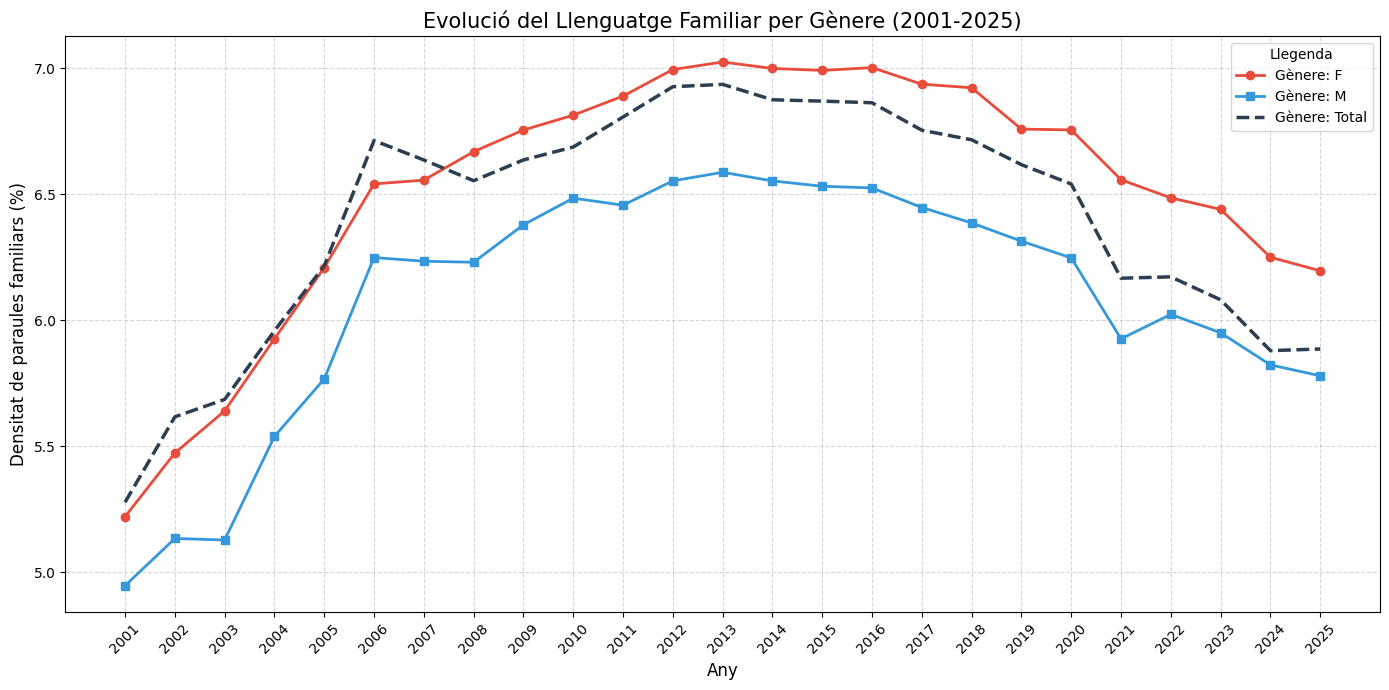


--- MITJANA D'ÍNDEX FAMILIAR PER GÈNERE ---
gender
F          6.698922
M          6.260579
Unknown    7.355102
Name: fam_index, dtype: float64


In [11]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. DICCIONARI FAMILIAR
family_dict = [
    'family', 'mother', 'father', 'son', 'daughter', 'brother', 'sister',
    'grandchild', 'grandchildren', 'grandson', 'granddaughter', 'grandmother',
    'grandfather', 'nana', 'papa', 'niece', 'nephew', 'cousin', 'aunt', 'uncle',
    'husband', 'wife', 'spouse', 'partner', 'loving', 'beloved', 'devoted',
    'survived', 'children', 'great-grandchildren', 'parent'
]

def get_family_index(text):
    if pd.isna(text): return 0
    text = str(text).lower()
    # Tokenització: paraules de 3+ lletres
    words = re.findall(r'\b\w{3,}\b', text)
    if not words: return 0
    
    # Comptem coincidències amb el diccionari familiar (coincidència exacta per paraula)
    count = sum(1 for word in words if word in family_dict)
    return (count / len(words)) * 100

# 2. CÀRREGA DEL FITXER AMB GÈNERE
try:
    # IMPORTANT: Usem el fitxer que conté la columna 'gender'
    df = pd.read_csv('obituaris_TOTAL_gender.csv')
    
    # Preparació de dades
    df['data'] = pd.to_datetime(df['data'], errors='coerce')
    df = df.dropna(subset=['biografia', 'data', 'gender'])
    df['any'] = df['data'].dt.year
    
    # Filtrem el rang d'anys
    df = df[(df['any'] >= 2001) & (df['any'] <= 2025)]

    print("Calculant índex familiar per gènere...")
    df['fam_index'] = df['biografia'].apply(get_family_index)

    # 3. AGRUPACIÓ PER ANY I GÈNERE (Taula Pivot)
    # Creem la taula on les columnes seran F, M, Unknown
    evolucio_genere_fam = df.groupby(['any', 'gender'])['fam_index'].mean().unstack()

    # Afegim la línia del TOTAL de la població
    evolucio_genere_fam['Total'] = df.groupby('any')['fam_index'].mean()

    # 4. VISUALITZACIÓ
    plt.figure(figsize=(14, 7))
    
    # Definim colors i estils per coherència
    estils_config = {
        'F': {'color': '#e74c3c', 'marker': 'o', 'ls': '-'},     # Vermell
        'M': {'color': '#3498db', 'marker': 's', 'ls': '-'},     # Blau
        'Total': {'color': '#2c3e50', 'marker': None, 'ls': '--'} # Negre/Gris fosc
    }
    
    for cat in ['F', 'M', 'Total']:
        if cat in evolucio_genere_fam.columns:
            config = estils_config.get(cat)
            plt.plot(evolucio_genere_fam.index, evolucio_genere_fam[cat], 
                     label=f'Gènere: {cat}', 
                     color=config['color'], 
                     marker=config['marker'], 
                     linestyle=config['ls'], 
                     linewidth=2.5 if cat == 'Total' else 2)
    
    plt.title('Evolució del Llenguatge Familiar per Gènere (2001-2025)', fontsize=15)
    plt.xlabel('Any', fontsize=12)
    plt.ylabel('Densitat de paraules familiars (%)', fontsize=12)
    plt.legend(title="Llegenda")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(range(2001, 2026), rotation=45)
    
    plt.tight_layout()
    plt.show()

    # 5. RESUM ESTADÍSTIC
    print("\n--- MITJANA D'ÍNDEX FAMILIAR PER GÈNERE ---")
    print(df.groupby('gender')['fam_index'].mean())

except Exception as e:
    print(f"S'ha produït un error: {e}")

Calculant índex lifestyle per gènere...


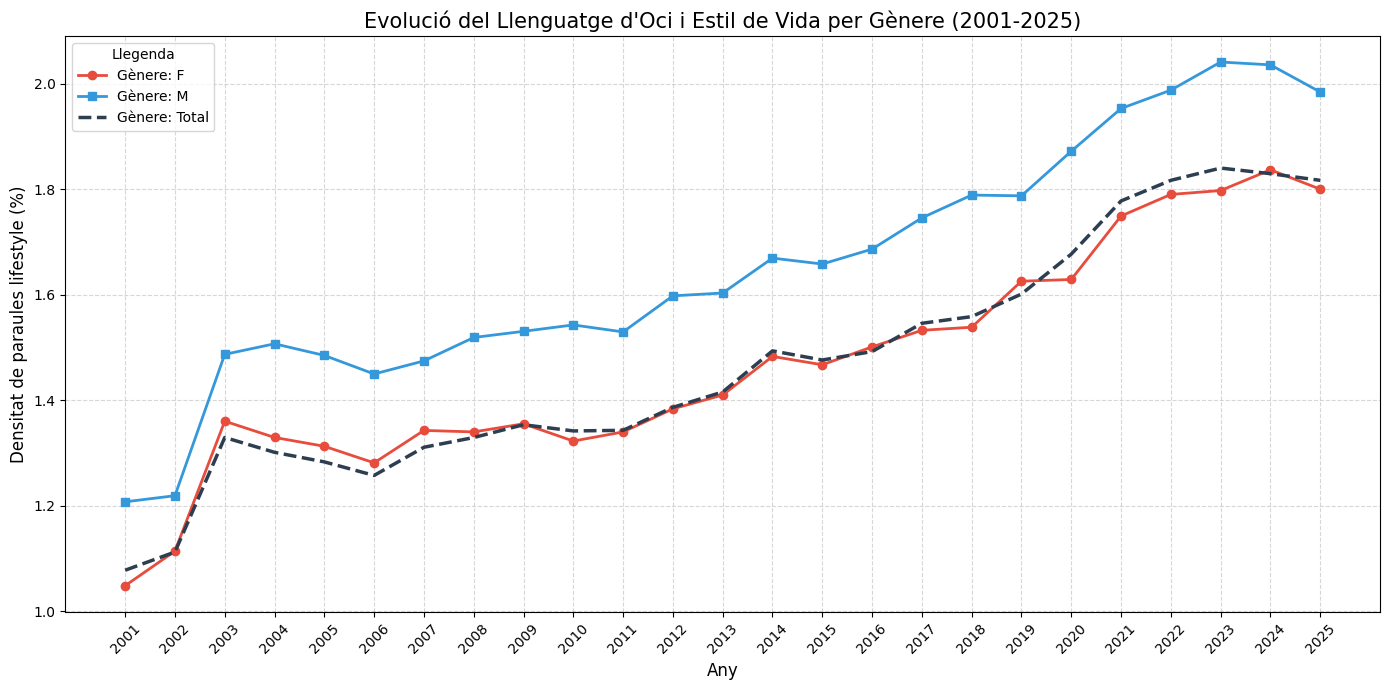


--- MITJANA D'ÍNDEX LIFESTYLE PER GÈNERE ---
gender
F          1.483080
M          1.684728
Unknown    0.596595
Name: life_index, dtype: float64


In [12]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# 1. DICCIONARI D'ESTIL DE VIDA (LIFESTYLE)
lifestyle_dict = [
    'travel', 'traveled', 'journey', 'adventure', 'hiking', 'sailing', 'golf', 
    'gardening', 'cooking', 'music', 'concerts', 'art', 'reading', 'books', 
    'nature', 'outdoors', 'animals', 'dogs', 'cats', 'pets', 'beach', 'lake',
    'traveling', 'passion', 'enjoyed', 'hobbies', 'photography', 'sports', 
    'fan', 'watching', 'food', 'wine', 'restaurant', 'club', 'fishing', 
    'camping', 'collector', 'painting', 'dance', 'dancing', 'volunteering'
]

def get_lifestyle_index(text):
    if pd.isna(text): return 0
    text = str(text).lower()
    
    words = re.findall(r'\b\w{3,}\b', text)
    if not words: return 0
    
    count = sum(1 for word in words if any(ls_word in word for ls_word in lifestyle_dict))
    return (count / len(words)) * 100


# 2. CÀRREGA DEL FITXER AMB GÈNERE
try:
    df = pd.read_csv('obituaris_TOTAL_gender.csv')
    
    df['data'] = pd.to_datetime(df['data'], errors='coerce')
    df = df.dropna(subset=['biografia', 'data', 'gender'])
    df['any'] = df['data'].dt.year
    
    df = df[(df['any'] >= 2001) & (df['any'] <= 2025)]

    print("Calculant índex lifestyle per gènere...")
    df['life_index'] = df['biografia'].apply(get_lifestyle_index)

    # 3. AGRUPACIÓ PER ANY I GÈNERE
    evolucio_genere_life = df.groupby(['any', 'gender'])['life_index'].mean().unstack()

    # Línia total
    evolucio_genere_life['Total'] = df.groupby('any')['life_index'].mean()

    # 4. VISUALITZACIÓ
    plt.figure(figsize=(14, 7))
    
    estils_config = {
        'F': {'color': '#e74c3c', 'marker': 'o', 'ls': '-'},
        'M': {'color': '#3498db', 'marker': 's', 'ls': '-'},
        'Total': {'color': '#2c3e50', 'marker': None, 'ls': '--'}
    }
    
    for cat in ['F', 'M', 'Total']:
        if cat in evolucio_genere_life.columns:
            config = estils_config.get(cat)
            plt.plot(
                evolucio_genere_life.index,
                evolucio_genere_life[cat],
                label=f'Gènere: {cat}',
                color=config['color'],
                marker=config['marker'],
                linestyle=config['ls'],
                linewidth=2.5 if cat == 'Total' else 2
            )

    plt.title('Evolució del Llenguatge d\'Oci i Estil de Vida per Gènere (2001-2025)', fontsize=15)
    plt.xlabel('Any', fontsize=12)
    plt.ylabel('Densitat de paraules lifestyle (%)', fontsize=12)
    plt.legend(title="Llegenda")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(range(2001, 2026), rotation=45)

    plt.tight_layout()
    plt.show()

    # 5. RESUM ESTADÍSTIC
    print("\n--- MITJANA D'ÍNDEX LIFESTYLE PER GÈNERE ---")
    print(df.groupby('gender')['life_index'].mean())

except Exception as e:
    print(f"S'ha produït un error: {e}")